# Regressão Linear
Vamos aplicar os conceitos de regressão linear no dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing)

In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import sys
from pathlib import Path

root = Path().resolve().parent  # aponta para machine-learning/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.regression import LinearRegression


SEED = 42
np.random.seed(SEED)


features, labels = fetch_california_housing(return_X_y=True)

features = torch.tensor(features, dtype=torch.float32)
labels = torch.tensor(labels, dtype=torch.float32).view(-1, 1)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.25
)
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25
)

Definindo a função de perca:
$$
    L(\theta) = \|X \theta - t\|_2^2
$$

In [10]:
def loss(X, t, theta):
    return torch.mean((X @ theta - t) ** 2)

Definindo os híper-parâmetros que serão utilizados

In [3]:
js = list(range(1,8))
batches_sizes = [2**j for j in js]

Realizando o treinamento usando a fórmula fechada e o algoritmo SGD

In [4]:
# Treinamento do modelo usando OLS com fórmula fechada
lr_ols = LinearRegression(
    features_train,
    labels_train,
    mode='ols'
)

# Treinamento do modelo usando SGD para cada tamanho de batch
linear_regressions = []

n_iterations = 10000
learning_rate = 0.001
stop_threshold = 1e-6


for size in batches_sizes:
    lr = LinearRegression(
        features_train,
        labels_train,
        mode='sgd',
        lr=learning_rate,
        n_iterations=n_iterations,
        stop_threshold=stop_threshold,
        batch_size=size
    )
    linear_regressions.append(lr)

Loss de validacao por tamanho de batch:
batch=  2 | SGD loss=252.980209 | OLS loss=0.535648
batch=  4 | SGD loss=231.261078 | OLS loss=0.535648
batch=  8 | SGD loss=521.231262 | OLS loss=0.535648
batch= 16 | SGD loss=35.474556 | OLS loss=0.535648
batch= 32 | SGD loss=20.577776 | OLS loss=0.535648
batch= 64 | SGD loss=32.069412 | OLS loss=0.535648
batch=128 | SGD loss=265.196564 | OLS loss=0.535648


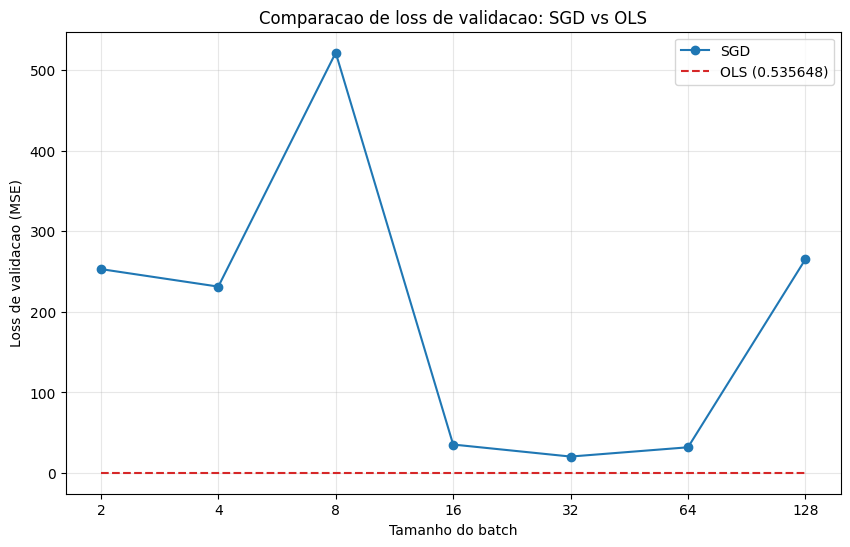

In [11]:
# Loss no conjunto de validacao para os modelos treinados
validation_losses_sgd = []
features_validation = torch.cat([torch.ones(features_validation.shape[0], 1), features_validation], dim=1)
validation_loss_ols = loss(features_validation, labels_validation, lr_ols.theta)

print("Loss de validacao por tamanho de batch:")
for batch_size, reg_sgd in zip(batches_sizes, linear_regressions):
    val_loss_sgd = loss(features_validation, labels_validation, reg_sgd.theta)
    validation_losses_sgd.append(val_loss_sgd)
    print(
        f"batch={batch_size:>3} | SGD loss={val_loss_sgd:.6f} | OLS loss={validation_loss_ols:.6f}"
    )

plt.figure(figsize=(10, 6))
plt.plot(batches_sizes, validation_losses_sgd, marker="o", label="SGD")
plt.hlines(
    y=validation_loss_ols,
    xmin=min(batches_sizes),
    xmax=max(batches_sizes),
    colors="tab:red",
    linestyles="--",
    label=f"OLS ({validation_loss_ols:.6f})",
)
plt.xscale("log", base=2)
plt.xticks(batches_sizes, batches_sizes)
plt.xlabel("Tamanho do batch")
plt.ylabel("Loss de validacao (MSE)")
plt.title("Comparacao de loss de validacao: SGD vs OLS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()